<a href="https://colab.research.google.com/github/Escalada-Matthew/CPE-312/blob/main/CPE312_HOA5_1_Escalada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 3.1 Decision Tree

Objective(s):

This activity aims to perform classification using Decision Tree

Intended Learning Outcomes (ILOs):
* Demonstrate how to build the model using Decision Tree.
* Demonstrate how to evaluate the performance of the model.
* Demonstrate how to create tree visualization of the model.

Resources:
* Jupyter Notebook
* kyphosis

Procedure:

Import the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Load the data and check the content of the dataframe using Pandas

In [4]:
df = pd.read_csv('kyphosis.csv')
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


Check the pairplot of the data

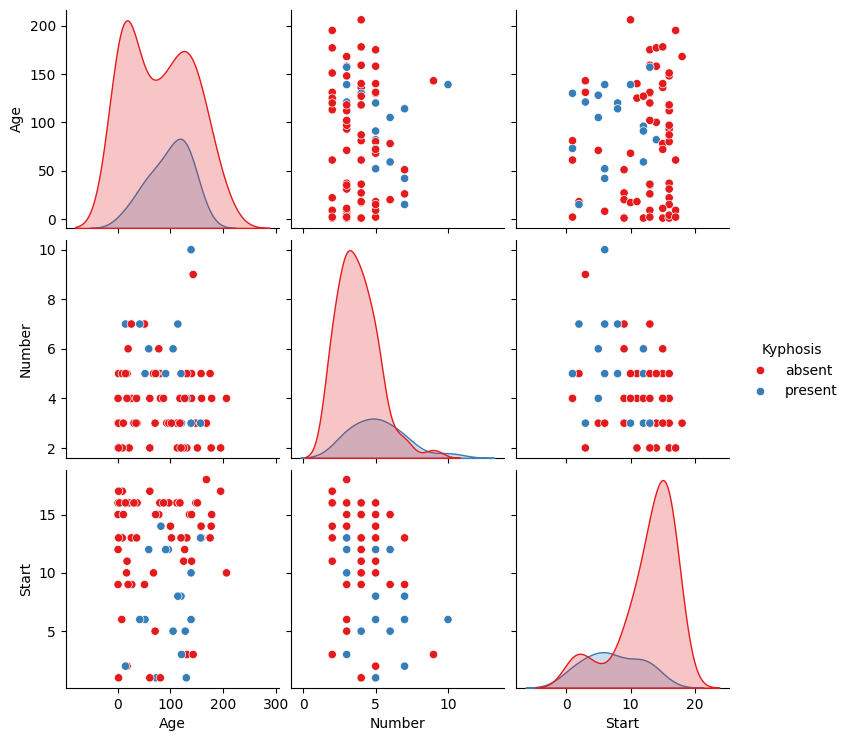

In [6]:
sns.pairplot(df,hue='Kyphosis',palette='Set1')

Interpret the result of the pairplot

The pairplot reveals an imbalanced dataset becauase it shows that there are more absent than present available.  While there are some overlaps between the two classes, there is a slight clustering that can be seen. There are no single feature that provides a clean separation between classes.

Build the model using Decision Tree

Split the data into training and test set

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X = df.drop('Kyphosis',axis=1)
y = df['Kyphosis']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

Train a single decision tree

In [10]:
from sklearn.tree import DecisionTreeClassifier

In [11]:
dtree = DecisionTreeClassifier()
dtree.fit(X_train,y_train)

DecisionTreeClassifier()

Determine how many nodes are present and what the depth of this (very large) tree is.

The number of nodes and the maximum actual depth.

In [12]:
dtree.tree_.node_count, dtree.tree_.max_depth

(21, 7)

Predict and evaluate the model

In [13]:
predictions = dtree.predict(X_test)

In [14]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [15]:
#evaluate the performance using classification report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

      absent       0.84      0.76      0.80        21
     present       0.17      0.25      0.20         4

    accuracy                           0.68        25
   macro avg       0.50      0.51      0.50        25
weighted avg       0.73      0.68      0.70        25



Interpret the precision, recall and f1-score

The model predicts the majority class which is the Absent class with a precision of 0.80, and an f1 score of 0.82. While it struggles with the minority class, the present class, the precision is only 0.40 and the recall is only 0.33. It has poor predictive power for this class due to the imbalance in data.

In [16]:
#evaluate the performance using confusion matrix
print(confusion_matrix(y_test,predictions))

[[16  5]
 [ 3  1]]


Interpret the performance using classification matrix

The model is able to accurately classify the absent class but struggles with detecting present cases. Out of 4 patients who had kyphosis, the model missed 3 which means that it had an error rate of 75%. This shows that the decision tree is biased towards the absent class due to the data imbalance.

In [17]:
#evaluate the performance using accuracy score
print(accuracy_score(y_test, predictions))

0.68


Interpret the performance of the model using accuracy score

68% accuracy means the decision tree has predicted 68% of the test cases. This might sound good but this metric is misleading because of the data imbalance, the score was based on correct predictions which were mostly for the majority class which was the absent class. It did poorly when identifying actual kyphosis cases.

Create a tree visualization of the model

In [18]:
from IPython.display import Image
from io import StringIO
from sklearn.tree import export_graphviz
import pydot

features = list(df.columns[1:])
features

['Age', 'Number', 'Start']

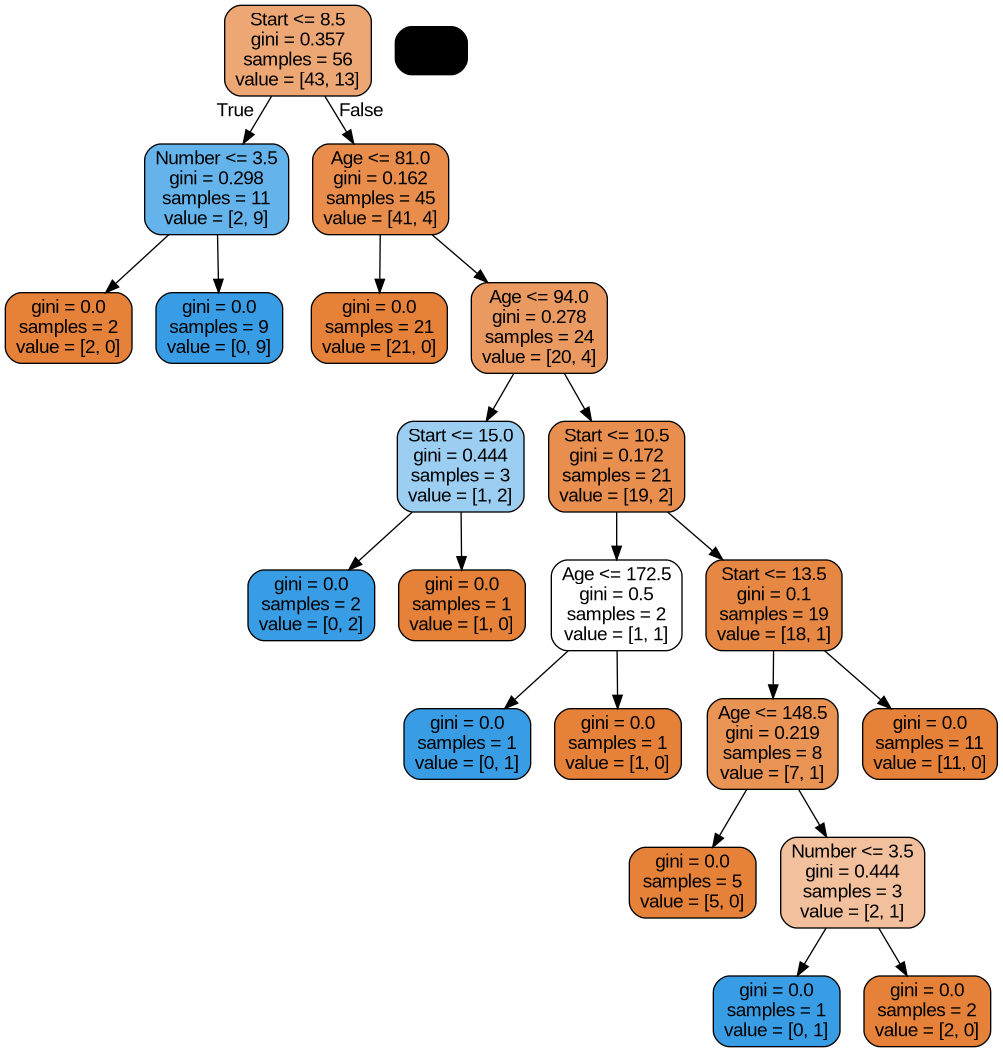

In [19]:
from io import StringIO
from IPython.display import Image, display
import pydotplus

from sklearn.tree import export_graphviz
dot_data = StringIO()

export_graphviz(dtree, out_file=dot_data, feature_names=features,filled=True,rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

    # View the tree image
filename = 'kyphosis .png'
graph.write_png(filename)
img = Image(filename=filename)
display(img)

Supplementary Activity:
* Choose your own dataset
* Import the dataset
* Determine the number of datapoints, columns and data types
* Remove unneccesary columns
* Do data cleaning such as removing empty values(NaN), replacing missing data .
* Perform descriptive statistics such as mean, median and mode
* Perform data visualization
* Build the model using Decision Tree
* Evaluate the model using classification report, accuracy and confusion matrix
* Create a tree visualization of the model

In [23]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine


wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print(df.info())


df = df.drop('nonflavanoid_phenols', axis=1)


df.loc[0, 'alcohol'] = np.nan
df = df.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [25]:

print("Mean:\n", df.mean())
print("\nMedian:\n", df.median())
print("\nMode:\n", df.mode().iloc[0])

Mean:
 alcohol                          12.993672
malic_acid                        2.339887
ash                               2.366158
alcalinity_of_ash                19.516949
magnesium                        99.587571
total_phenols                     2.292260
flavanoids                        2.023446
proanthocyanins                   1.586949
color_intensity                   5.054802
hue                               0.956983
od280/od315_of_diluted_wines      2.604294
proline                         745.096045
target                            0.943503
dtype: float64

Median:
 alcohol                          13.05
malic_acid                        1.87
ash                               2.36
alcalinity_of_ash                19.50
magnesium                        98.00
total_phenols                     2.35
flavanoids                        2.13
proanthocyanins                   1.55
color_intensity                   4.68
hue                               0.96
od280/od315_of_dilu

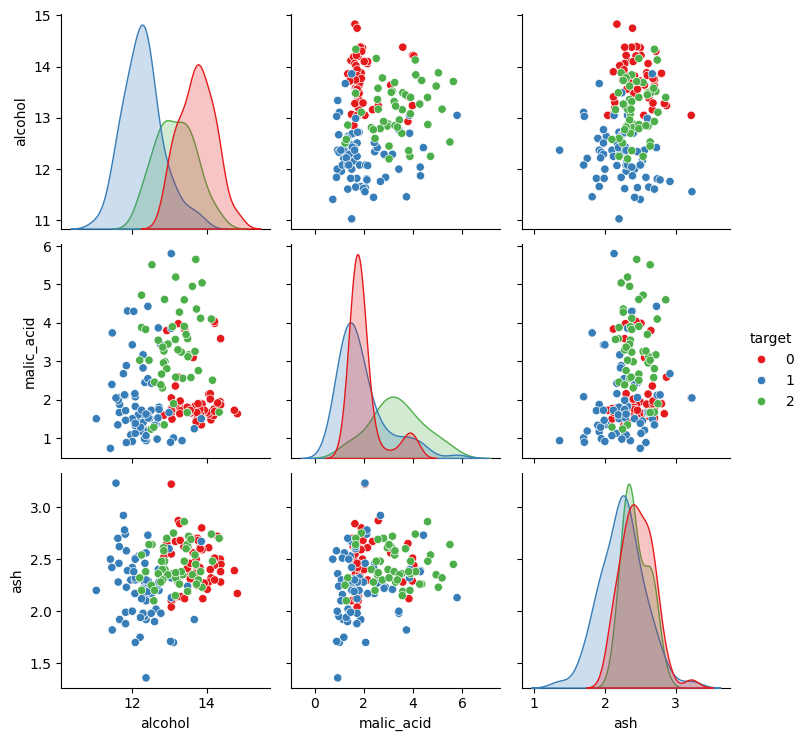

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

subset_cols = ['alcohol', 'malic_acid', 'ash', 'target']
sns.pairplot(df[subset_cols], hue='target', palette='Set1')
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)


dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)


predictions = dtree.predict(X_test)

print("Classification Report:\n", classification_report(y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))
print("Accuracy Score:\n", accuracy_score(y_test, predictions))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.95      0.86      0.90        21
           2       0.82      1.00      0.90        14

    accuracy                           0.93        54
   macro avg       0.92      0.93      0.93        54
weighted avg       0.93      0.93      0.93        54

Confusion Matrix:
 [[18  1  0]
 [ 0 18  3]
 [ 0  0 14]]
Accuracy Score:
 0.9259259259259259


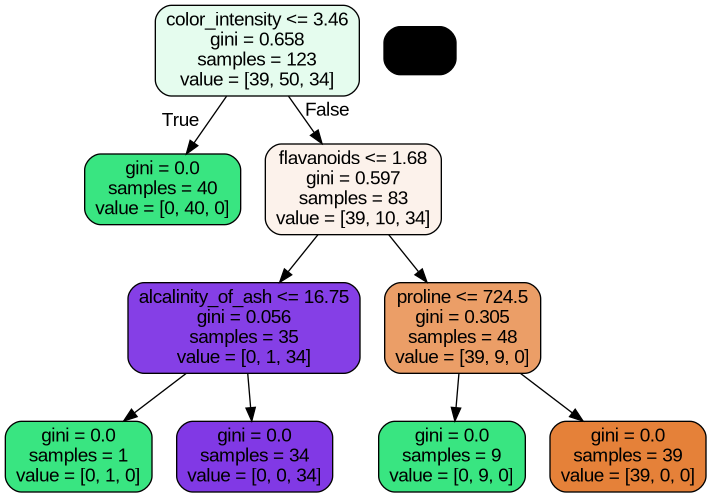

In [29]:
from IPython.display import Image, display
from io import StringIO
from sklearn.tree import export_graphviz
import pydotplus

features = list(X.columns)


dot_data = StringIO()
export_graphviz(dtree, out_file=dot_data, feature_names=features, filled=True, rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

filename = 'wine_tree.png'
graph.write_png(filename)
img = Image(filename=filename)
display(img)

Conclusion

During this supplementary, I was able to learn how to apply the decision tree classifier in my activity. I applied it on the wine dataset that classified wines into three categories based on chemical composition. The model was able to achieve an accuracy of 92%, meaning that the model performed well on all 3 classes.